# **Exam mark prediction using Multiple Linear Regression-3 independent**

### *Import Libraries*

In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### *Load Dataset from Local Directory*

In [59]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data (1).csv


### *Load Dataset*

In [60]:
dataset = pd.read_csv('data.csv')

### *Load Summarize*

In [61]:
print(dataset.shape)
print(dataset.head(5))

(201, 4)
   hours  age  internet  marks
0   6.83   15         1  78.50
1   6.56   16         0  76.74
2    NaN   17         1  78.68
3   5.67   18         0  71.82
4   8.67   19         1  84.19


### *Finding & Removing NA values from our Features X*

In [62]:
dataset.columns[dataset.isna().any()]

Index(['hours'], dtype='object')

In [63]:
dataset.hours = dataset.hours.fillna(dataset.hours.mean())

### *Segregate Dataset into Input X & Output Y*

In [64]:
X = dataset.iloc[:, :-1].values
print(X.shape)
X

(201, 3)


array([[ 6.83      , 15.        ,  1.        ],
       [ 6.56      , 16.        ,  0.        ],
       [ 6.99061538, 17.        ,  1.        ],
       [ 5.67      , 18.        ,  0.        ],
       [ 8.67      , 19.        ,  1.        ],
       [ 7.55      , 20.        ,  0.        ],
       [ 6.67      , 15.        ,  0.        ],
       [ 8.99      , 16.        ,  0.        ],
       [ 6.99061538, 17.        ,  1.        ],
       [ 6.75      , 18.        ,  0.        ],
       [ 6.59      , 19.        ,  0.        ],
       [ 8.56      , 20.        ,  1.        ],
       [ 7.75      , 15.        ,  0.        ],
       [ 7.9       , 16.        ,  1.        ],
       [ 8.19      , 17.        ,  0.        ],
       [ 6.55      , 18.        ,  1.        ],
       [ 6.36      , 19.        ,  0.        ],
       [ 8.44      , 20.        ,  1.        ],
       [ 8.41      , 15.        ,  0.        ],
       [ 7.67      , 16.        ,  1.        ],
       [ 7.42      , 17.        ,  1.   

In [65]:
Y = dataset.iloc[:, -1].values
Y

array([78.5 , 76.74, 78.68, 71.82, 84.19, 81.18, 76.99, 85.46, 70.66,
       77.82, 75.37, 83.88, 79.5 , 80.76, 83.08, 76.03, 76.04, 85.11,
       82.5 , 80.58, 82.18, 83.36, 70.67, 75.02, 70.96, 83.33, 74.75,
       75.65, 74.15, 80.17, 82.27, 76.14, 71.1 , 84.35, 83.08, 76.76,
       81.24, 78.21, 73.08, 83.23, 70.27, 86.41, 71.1 , 82.84, 82.38,
       72.96, 77.46, 70.11, 72.38, 71.41, 72.22, 77.77, 84.44, 71.45,
       82.21, 85.48, 75.03, 86.65, 70.9 , 71.7 , 73.61, 79.41, 76.19,
       80.43, 85.78, 70.06, 81.25, 81.7 , 69.27, 82.79, 71.8 , 71.79,
       74.97, 78.61, 77.59, 72.33, 72.08, 77.33, 70.05, 73.34, 84.  ,
       82.93, 76.63, 75.36, 77.29, 72.87, 73.4 , 81.74, 71.85, 84.6 ,
       79.56, 82.1 , 72.08, 79.1 , 81.01, 76.48, 75.39, 68.57, 83.64,
       82.3 , 75.18, 82.03, 82.99, 79.26, 77.55, 77.07, 72.1 , 73.25,
       74.25, 70.58, 81.08, 75.04, 76.38, 80.86, 78.42, 74.44, 70.34,
       85.04, 73.61, 75.55, 76.2 , 82.69, 76.83, 79.53, 83.57, 85.95,
       76.02, 77.65,

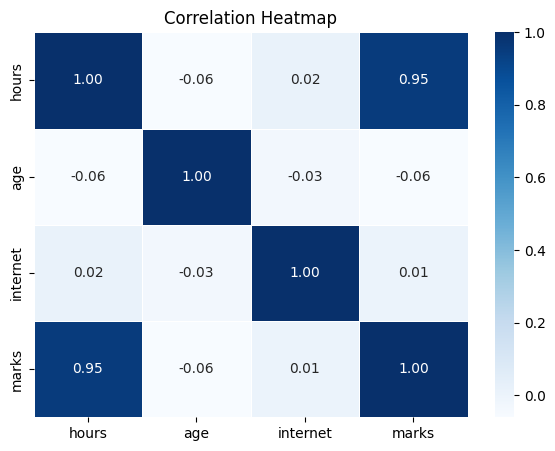

In [66]:
plt.figure(figsize=(7, 5))

# Correlation matrix calculate panradhu
corr_matrix = dataset.corr()

# Heatmap plot
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Train-Test Split & Model Training

In [67]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# FEATURE SCALING (Model train panradhuku munnadi)

In [68]:
sc = StandardScaler()

# Train data-vukku fit_transform

In [69]:
X_train_scaled = sc.fit_transform(X_train)

# Test data-vukku transform ONLY (fit panna koodadhu)

In [70]:
X_test_scaled = sc.transform(X_test)

# Model Training (Scaled Data-va vachu train panrom)

In [71]:
model = LinearRegression()
model.fit(X_train_scaled, Y_train)

LinearRegression()

# Model Score Check

In [72]:
Y_pred = model.predict(X_test_scaled)
print("R2 Score:", r2_score(Y_test,Y_pred))

R2 Score: 0.9465537444171312


# Custom Input Predict Panrom-na, antha Input-aiyum scale pannanum

In [73]:
custom_input = [[9.2, 20, 0]]
custom_input_scaled = sc.transform(custom_input)

In [74]:
predicted_result = model.predict(custom_input_scaled)
print("Predicted Output:", predicted_result[0])

Predicted Output: 86.2044276428165


In [75]:
import plotly.express as px

# Plotly Interactive 4D Scatter Plot
fig = px.scatter_3d(
    dataset,
    x=dataset.columns[0],  # Feature 1 (Hours)
    y=dataset.columns[1],  # Feature 2 (Age)
    z=dataset.columns[2],  # Feature 3 (Internet)
    color=dataset.columns[-1],  # Target Y (Marks) - Color Mapping
    color_continuous_scale='Viridis',
    title="4D Data Visualization (3 Features + Target as Color)"
)

fig.show()

# 1. Custom Input Define Panrom

In [76]:
custom_input_raw = np.array([[7, 30, 1]])

# Custom input-ah scale panrom

In [77]:
custom_input_scaled = sc.transform(custom_input_raw)

# Prediction Calculate Panrom

In [78]:
predicted_mark = model.predict(custom_input_scaled)[0]

print("--- Custom Prediction Output ---")
print(f"Hours: 7, Age: 30, Internet: 1")
print(f"Predicted Mark (Y_pred): {predicted_mark:.2f}")

--- Custom Prediction Output ---
Hours: 7, Age: 30, Internet: 1
Predicted Mark (Y_pred): 77.54


# Plotly Visualization Data Prepare Panrom

In [79]:
df_plot = pd.DataFrame(X_train_scaled, columns=['hours', 'age', 'internet'])
df_plot['Marks'] = Y_train
df_plot['Type'] = 'Training Data'

# Custom Prediction Point Addition

In [80]:
custom_df = pd.DataFrame({
    'hours': [custom_input_scaled[0, 0]],
    'age': [custom_input_scaled[0, 1]],
    'internet': [custom_input_scaled[0, 2]],
    'Marks': [predicted_mark],
    'Type': ['CUSTOM PREDICTION']
})

# Combine Both Datasets

In [81]:
combined_df = pd.concat([df_plot, custom_df], ignore_index=True)

# Plotly Express 4D Interactive Scatter Plot

In [82]:
fig = px.scatter_3d(
    combined_df,
    x='hours',
    y='age',
    z='internet',
    color='Marks',
    symbol='Type',
    symbol_sequence=['circle', 'diamond'],  # Custom point diamond shape-la theriya
    size='Marks',                           # Point size based on marks
    size_max=18,
    color_continuous_scale='Viridis',
    title=f'4D Plotly Graph: Custom Prediction (Predicted Mark: {predicted_mark:.2f})'
)

fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    scene=dict(
        xaxis_title='Hours (Scaled)',
        yaxis_title='Age (Scaled)',
        zaxis_title='Internet (Scaled)'
    )
)

fig.show()